# 🏙️ DỰ BÁO GIÁ BẤT ĐỘNG SẢN NEW YORK (NYC REAL ESTATE)
### Mô hình: **CatBoost Regressor + Log Transform Target**
*Dự án: NYC_Dashboard (Dữ liệu thị trường 2025 - 2026)*
---


In [3]:
# ============================================================
# 1. CÀI ĐẶT & IMPORT THƯ VIỆN
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, HTML

# Cấu hình font & style cho biểu đồ
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.0
print("✅ Đã nạp đầy đủ các thư viện thành công!")


✅ Đã nạp đầy đủ các thư viện thành công!


In [4]:
# ============================================================
# 2. ĐỌC DỮ LIỆU SẠCH (DATA WAREHOUSE / NYC_DASHBOARD)
# ============================================================
file_path = os.path.join("data", "data clean", "DATA.csv")
print(f"📂 Đang đọc dữ liệu sạch: {file_path}...")

df = pd.read_csv(file_path, low_memory=False)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 2.1 Kiểm tra và làm sạch biến mục tiêu (Target)
target = "sale_price"
if target not in df.columns:
    raise ValueError(f"Không tìm thấy cột '{target}' trong dữ liệu.")

df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target])

# Lọc bỏ các giao dịch nội bộ/cho tặng (<= 10,000 USD)
df = df[df[target] >= 10000].copy()

# 2.2 Lấy mẫu tối đa 60,000 dòng để huấn luyện mượt mà
if len(df) > 60000:
    df = df.sample(n=60000, random_state=42).reset_index(drop=True)

# Kiểm tra khung thời gian thực tế
date_check = pd.to_datetime(df.get('sale_date_parsed', df.get('sale_date')), errors='coerce')
min_date = date_check.min().strftime('%m/%Y') if date_check.notna().any() else '04/2025'
max_date = date_check.max().strftime('%m/%Y') if date_check.notna().any() else '03/2026'

print(f"📊 Số lượng bản ghi hợp lệ: {len(df):,} dòng x {df.shape[1]} cột")
print(f"📅 Giai đoạn dữ liệu ghi nhận: từ {min_date} đến {max_date} (NYC 2025 - 2026)")
print(f"💰 Khoảng giá: từ ${df[target].min():,.0f} đến ${df[target].max():,.0f}")
print(f"📍 Giá trung vị (Median): ${df[target].median():,.0f}")


📂 Đang đọc dữ liệu sạch: data\data clean\DATA.csv...
📊 Số lượng bản ghi hợp lệ: 47,003 dòng x 35 cột
📅 Giai đoạn dữ liệu ghi nhận: từ 04/2025 đến 03/2026 (NYC 2025 - 2026)
💰 Khoảng giá: từ $10,000 đến $2,957,225
📍 Giá trung vị (Median): $865,000


In [5]:
# ============================================================
# 3. TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN & CÔNG TRÌNH (FEATURE ENGINEERING)
# ============================================================
# 3.1 Xử lý ngày và trích xuất năm/tháng/quý
if 'sale_date_parsed' in df.columns:
    date_series = pd.to_datetime(df['sale_date_parsed'], errors='coerce')
elif 'sale_date' in df.columns:
    date_series = pd.to_datetime(df['sale_date'], errors='coerce')
else:
    date_series = pd.Series(pd.to_datetime('2025-04-01'), index=df.index)

df['sale_year'] = date_series.dt.year.fillna(2025).astype(int)
df['sale_month'] = date_series.dt.month.fillna(6).astype(int)
df['sale_quarter'] = date_series.dt.quarter.fillna(2).astype(int)

# 3.2 Tuổi công trình (Building Age)
if 'year_built' in df.columns and 'sale_year' in df.columns:
    df['year_built'] = pd.to_numeric(df['year_built'], errors='coerce').fillna(1950)
    df['building_age'] = df['sale_year'] - df['year_built']
    df.loc[df['building_age'] < 0, 'building_age'] = 0
else:
    df['building_age'] = pd.to_numeric(df.get('building_age', 20), errors='coerce').fillna(20)
    df.loc[df['building_age'] < 0, 'building_age'] = 0

# 3.3 Tổng số căn hộ (Total Units)
if 'residential_units' in df.columns and 'commercial_units' in df.columns:
    res_units = pd.to_numeric(df['residential_units'], errors='coerce').fillna(0)
    com_units = pd.to_numeric(df['commercial_units'], errors='coerce').fillna(0)
    df['total_units_calculated'] = res_units + com_units
    df['commercial_units'] = com_units
    df['residential_units'] = res_units
else:
    df['total_units_calculated'] = pd.to_numeric(df.get('total_units', 1), errors='coerce').fillna(1)

# 3.4 Tỷ lệ diện tích xây dựng / diện tích đất & diện tích trên mỗi căn
if 'gross_sqft' in df.columns and 'land_sqft' in df.columns:
    gross = pd.to_numeric(df['gross_sqft'], errors='coerce').fillna(0)
    land = pd.to_numeric(df['land_sqft'], errors='coerce').replace(0, np.nan)
    df['gross_sqft'] = gross
    df['land_sqft'] = land.fillna(0)
    df['building_land_ratio'] = (gross / land).fillna(1.0)
    df['gross_per_unit'] = (gross / df['total_units_calculated'].clip(lower=1)).fillna(0)

print("✅ Hoàn tất Feature Engineering: sale_year, sale_month, building_age, total_units_calculated, building_land_ratio")


✅ Hoàn tất Feature Engineering: sale_year, sale_month, building_age, total_units_calculated, building_land_ratio


In [6]:
# ============================================================
# 4. LOẠI BỎ BIẾN GÂY DATA LEAKAGE & LOG TRANSFORM TARGET
# ============================================================
drop_columns = [
    'sale_price',           # Biến mục tiêu
    'price_per_sqft',       # Rò rỉ giá (tính từ sale_price / sqft)
    'price_per_sqft_real',  # Rò rỉ giá
    'address',              # Quá nhiều tên đường phân mảnh
    'sale_date',            # Đã tách thành năm/tháng/quý
    'sale_date_parsed',
    'ease_ment',
    'easement'
]

X = df.drop(columns=[col for col in drop_columns if col in df.columns]).copy()
y_original = df[target].copy()

# LOG TRANSFORM: Chuẩn hóa phân phối lệch phải của giá BĐS
y = np.log1p(y_original)

# Phân loại biến chuỗi và biến số
categorical_columns = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

# Xử lý Missing Values
for col in categorical_columns:
    X[col] = X[col].fillna('Unknown').astype(str)

for col in numerical_columns:
    X[col] = X[col].replace([np.inf, -np.inf], np.nan)
    median_val = X[col].median()
    if pd.isna(median_val):
        median_val = 0
    X[col] = X[col].fillna(median_val)

print(f"🎯 Tổng số đặc trưng đầu vào (Features): {X.shape[1]}")
print(f"📌 Biến phân loại (Categorical): {len(categorical_columns)} | Biến số học (Numerical): {len(numerical_columns)}")


🎯 Tổng số đặc trưng đầu vào (Features): 33
📌 Biến phân loại (Categorical): 8 | Biến số học (Numerical): 25


In [7]:
# ============================================================
# 5. CHIA TẬP TRAIN / TEST (80% - 20%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🏋️ Tập Train (80%): {X_train.shape[0]:,} dòng x {X_train.shape[1]} cột")
print(f"🧪 Tập Test  (20%): {X_test.shape[0]:,} dòng x {X_test.shape[1]} cột")


🏋️ Tập Train (80%): 37,602 dòng x 33 cột
🧪 Tập Test  (20%): 9,401 dòng x 33 cột


In [8]:
# ============================================================
# 6. HUẤN LUYỆN MÔ HÌNH CATBOOST REGRESSOR
# ============================================================
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    l2_leaf_reg=5,
    random_seed=42,
    verbose=100
)

print("\n⏳ Đang huấn luyện CatBoost (khoảng 1-2 phút)...\n")
model.fit(
    X_train, y_train,
    cat_features=categorical_columns,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150,
    verbose=100
)
print("\n🎉 Huấn luyện hoàn tất!")



⏳ Đang huấn luyện CatBoost (khoảng 1-2 phút)...

0:	learn: 0.6932683	test: 0.6933261	best: 0.6933261 (0)	total: 267ms	remaining: 8m 53s
100:	learn: 0.4889073	test: 0.4900147	best: 0.4900147 (100)	total: 12.6s	remaining: 3m 56s
200:	learn: 0.4726393	test: 0.4766182	best: 0.4766182 (200)	total: 25.1s	remaining: 3m 44s
300:	learn: 0.4638090	test: 0.4703768	best: 0.4703768 (300)	total: 41.8s	remaining: 3m 55s
400:	learn: 0.4558175	test: 0.4646877	best: 0.4646877 (400)	total: 58.5s	remaining: 3m 53s
500:	learn: 0.4493601	test: 0.4608039	best: 0.4608039 (500)	total: 1m 14s	remaining: 3m 43s
600:	learn: 0.4444443	test: 0.4580250	best: 0.4580250 (600)	total: 1m 30s	remaining: 3m 30s
700:	learn: 0.4406909	test: 0.4562513	best: 0.4562513 (700)	total: 1m 48s	remaining: 3m 21s
800:	learn: 0.4371934	test: 0.4547280	best: 0.4547280 (800)	total: 2m 5s	remaining: 3m 7s
900:	learn: 0.4339954	test: 0.4535772	best: 0.4535772 (900)	total: 2m 14s	remaining: 2m 44s
1000:	learn: 0.4312533	test: 0.4525405	be

In [9]:
# ============================================================
# 7. HOÀN NGUYÊN GIÁ TRỊ & ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
# ============================================================
y_pred_log = model.predict(X_test)
y_pred = np.maximum(0, np.expm1(y_pred_log))
y_actual = np.expm1(y_test).values

MAE = mean_absolute_error(y_actual, y_pred)
RMSE = np.sqrt(mean_squared_error(y_actual, y_pred))
R2 = r2_score(y_actual, y_pred)

mask = y_actual != 0
MAPE = np.mean(np.abs((y_actual[mask] - y_pred[mask]) / y_actual[mask])) * 100

print("="*55)
print("         KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CATBOOST")
print("="*55)
print(f"🔹 MAE  (Sai số tuyệt đối trung bình):  ${MAE:,.2f}")
print(f"🔹 RMSE (Sai số bình phương trung bình): ${RMSE:,.2f}")
print(f"🔹 R²   (Hệ số xác định):                {R2:.4f} ({R2*100:.2f}%)")
print(f"🔹 MAPE (Tỷ lệ sai số phần trăm TB):     {MAPE:.2f}%")
print("="*55)


         KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH CATBOOST
🔹 MAE  (Sai số tuyệt đối trung bình):  $260,831.25
🔹 RMSE (Sai số bình phương trung bình): $403,632.24
🔹 R²   (Hệ số xác định):                0.5616 (56.16%)
🔹 MAPE (Tỷ lệ sai số phần trăm TB):     43.53%


In [10]:
# ============================================================
# 8. BẢNG MẪU KẾT QUẢ DỰ BÁO (ACTUAL VS PREDICTED)
# ============================================================
results = pd.DataFrame({
    "Giá thực tế (Actual)": y_actual,
    "Giá AI dự báo (Predicted)": y_pred
})

results["Sai số tuyệt đối ($)"] = np.abs(results["Giá thực tế (Actual)"] - results["Giá AI dự báo (Predicted)"])
results["Tỷ lệ sai số (%)"] = (results["Sai số tuyệt đối ($)"] / results["Giá thực tế (Actual)"]) * 100

print("📋 15 Mẫu kết quả dự báo ngẫu nhiên trên tập kiểm thử:")
display(results.sample(15, random_state=42).reset_index(drop=True))


📋 15 Mẫu kết quả dự báo ngẫu nhiên trên tập kiểm thử:


,Giá thực tế (Actual),Giá AI dự báo (Predicted),Sai số tuyệt đối ($),Tỷ lệ sai số (%)
0,1520000.0,8.579608e+05,662039.150241,43.555207
1,1298269.0,1.094473e+06,203795.953664,15.697514
2,930000.0,9.610391e+05,31039.101308,3.337538
3,1300000.0,9.121417e+05,387858.272204,29.835252
4,1130000.0,1.034611e+06,95389.147630,8.441517
5,1510000.0,1.497435e+06,12565.127742,0.832128
6,300000.0,5.031252e+05,203125.248580,67.708416
7,707500.0,7.565034e+05,49003.350995,6.926269
8,1950000.0,1.289545e+06,660455.493354,33.869512
9,795000.0,6.562126e+05,138787.354931,17.457529


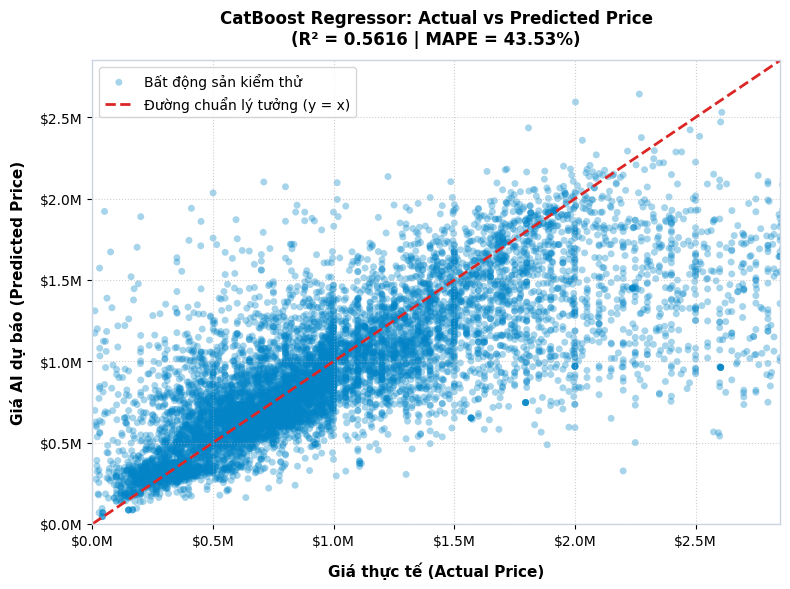

In [11]:
# ============================================================
# 9. BIỂU ĐỒ SCATTER: GIÁ THỰC TẾ VS DỰ BÁO
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.35, color='#0284c7', edgecolors='none', s=25, label='Bất động sản kiểm thử')

max_view = min(max(np.percentile(y_actual, 99.5), np.percentile(y_pred, 99.5)), 15000000)
plt.plot([0, max_view], [0, max_view], '--', color='#dc2626', linewidth=2, label='Đường chuẩn lý tưởng (y = x)')

plt.xlim(0, max_view)
plt.ylim(0, max_view)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y*1e-6:.1f}M"))

plt.xlabel('Giá thực tế (Actual Price)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Giá AI dự báo (Predicted Price)', fontsize=11, fontweight='bold', labelpad=10)
plt.title(f'CatBoost Regressor: Actual vs Predicted Price\n(R² = {R2:.4f} | MAPE = {MAPE:.2f}%)', fontsize=12, fontweight='bold', pad=12)
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


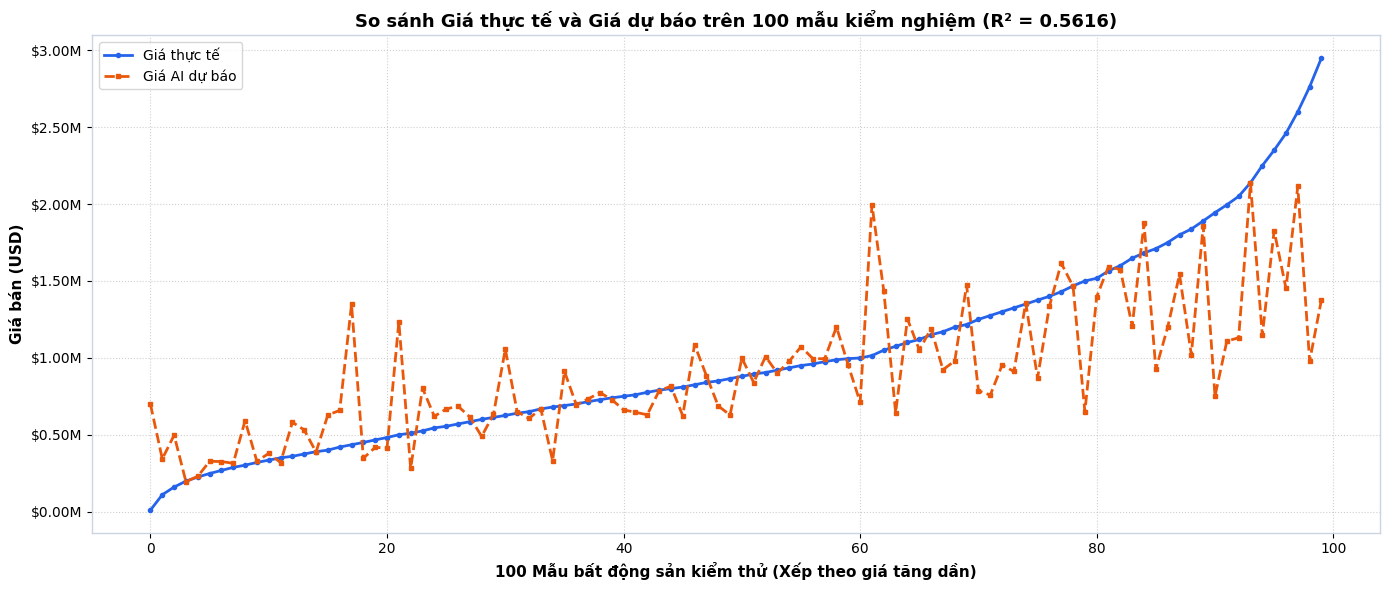

In [12]:
# ============================================================
# 10. BIỂU ĐỒ ĐƯỜNG: SO SÁNH 100 CĂN NHÀ KIỂM NGHIỆM
# ============================================================
comparison = pd.DataFrame({
    "Actual_Price": y_actual,
    "Predicted_Price": y_pred
}).sort_values("Actual_Price").reset_index(drop=True)

number_samples = min(100, len(comparison))
indices = np.linspace(0, len(comparison) - 1, number_samples).astype(int)
plot_data = comparison.iloc[indices].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(plot_data.index, plot_data["Actual_Price"], marker="o", markersize=3, color='#2563eb', linewidth=2, label="Giá thực tế")
plt.plot(plot_data.index, plot_data["Predicted_Price"], marker="s", markersize=3, color='#ea580c', linewidth=2, linestyle='--', label="Giá AI dự báo")

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y*1e-6:.2f}M"))
plt.xlabel("100 Mẫu bất động sản kiểm thử (Xếp theo giá tăng dần)", fontsize=11, fontweight='bold')
plt.ylabel("Giá bán (USD)", fontsize=11, fontweight='bold')
plt.title(f"So sánh Giá thực tế và Giá dự báo trên 100 mẫu kiểm nghiệm (R² = {R2:.4f})", fontsize=13, fontweight='bold')
plt.legend(frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


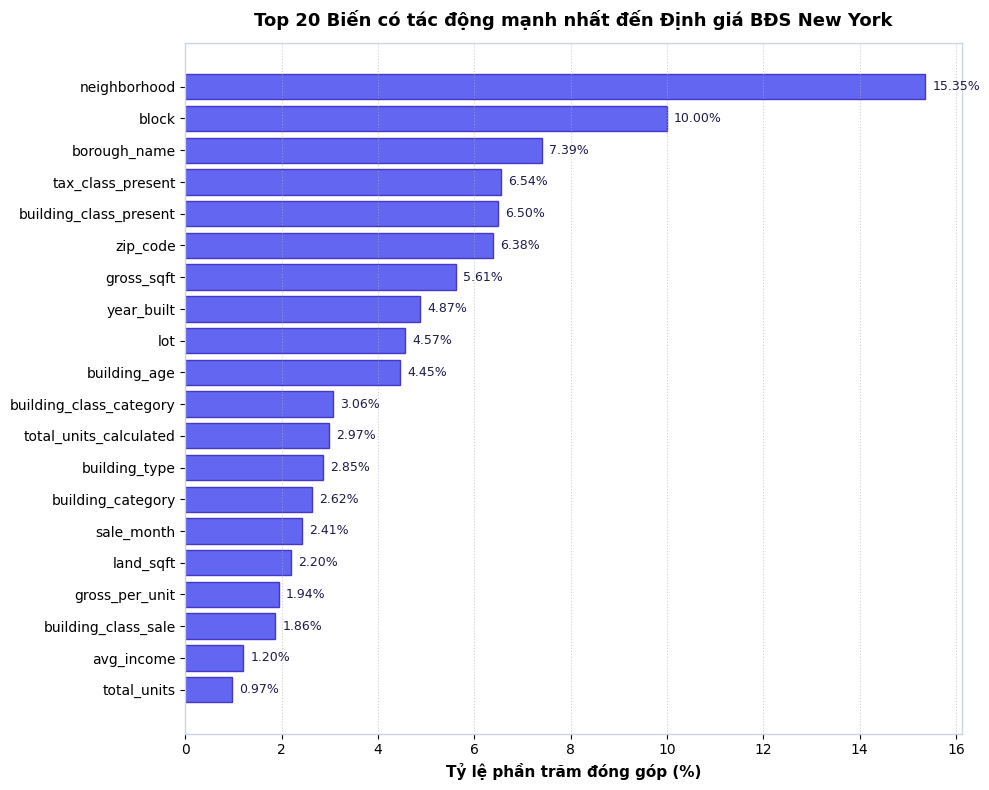

In [13]:
# ============================================================
# 11. TOP 20 YẾU TỐ ẢNH HƯỞNG ĐẾN GIÁ (FEATURE IMPORTANCE)
# ============================================================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance (%)": model.feature_importances_
}).sort_values("Importance (%)", ascending=False)

top20 = importance.head(20).sort_values("Importance (%)", ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(top20["Feature"], top20["Importance (%)"], color='#6366f1', edgecolor='#4338ca')
plt.xlabel("Tỷ lệ phần trăm đóng góp (%)", fontsize=11, fontweight='bold')
plt.title("Top 20 Biến có tác động mạnh nhất đến Định giá BĐS New York", fontsize=13, fontweight='bold', pad=12)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.15, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va='center', fontsize=9, color='#1e1b4b')

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 12. HÀM DỰ BÁO BĐS NÂNG CAO (HIỂN THỊ THẺ BÁO CÁO HTML TRỰC QUAN)
# ============================================================
def predict_property_analysis(
    borough_name="Manhattan",
    neighborhood="MIDTOWN EAST",
    gross_sqft=2000,
    land_sqft=1500,
    year_built=2015,
    residential_units=1,
    commercial_units=0,
    current_year=2025,
    current_month=4,
    forecast_horizon_months=12
):
    # 1. Tính toán mốc thời gian tương lai
    total_months = current_month + forecast_horizon_months
    future_year = current_year + (total_months - 1) // 12
    future_month = ((total_months - 1) % 12) + 1
    future_quarter = (future_month - 1) // 3 + 1
    
    # 2. Tạo bản ghi Hiện tại
    current_row = pd.DataFrame(index=[0], columns=X.columns)
    hood_match = df[df['neighborhood'].astype(str).str.upper() == str(neighborhood).upper()]
    
    for col in numerical_columns:
        if len(hood_match) > 0 and col in hood_match.columns and not pd.isna(hood_match[col].median()):
            current_row.loc[0, col] = hood_match[col].median()
        else:
            current_row.loc[0, col] = X_train[col].median()
            
    for col in categorical_columns:
        if len(hood_match) > 0 and col in hood_match.columns and len(hood_match[col].mode()) > 0:
            current_row.loc[0, col] = str(hood_match[col].mode().iloc[0])
        else:
            current_row.loc[0, col] = str(X_train[col].mode().iloc[0]) if len(X_train[col].mode()) > 0 else 'Unknown'
    
    # Gán giá trị người dùng nhập
    if 'borough_name' in X.columns: current_row['borough_name'] = str(borough_name)
    if 'borough' in X.columns:
        b_map = {'Manhattan': 1, 'Bronx': 2, 'Brooklyn': 3, 'Queens': 4, 'Staten Island': 5}
        current_row['borough'] = b_map.get(borough_name, 1)
    if 'neighborhood' in X.columns: current_row['neighborhood'] = str(neighborhood)
    if 'gross_sqft' in X.columns: current_row['gross_sqft'] = gross_sqft
    if 'land_sqft' in X.columns: current_row['land_sqft'] = land_sqft
    if 'year_built' in X.columns: current_row['year_built'] = year_built
    if 'building_age' in X.columns: current_row['building_age'] = max(0, current_year - year_built)
    if 'residential_units' in X.columns: current_row['residential_units'] = residential_units
    if 'commercial_units' in X.columns: current_row['commercial_units'] = commercial_units
    if 'total_units_calculated' in X.columns: current_row['total_units_calculated'] = residential_units + commercial_units
    if 'building_land_ratio' in X.columns: current_row['building_land_ratio'] = gross_sqft / max(1, land_sqft)
    if 'gross_per_unit' in X.columns: current_row['gross_per_unit'] = gross_sqft / max(1, residential_units + commercial_units)
    if 'sale_year' in X.columns: current_row['sale_year'] = current_year
    if 'sale_month' in X.columns: current_row['sale_month'] = current_month
    if 'sale_quarter' in X.columns: current_row['sale_quarter'] = (current_month - 1) // 3 + 1
    
    # 3. Tạo bản ghi Tương lai
    future_row = current_row.copy()
    if 'sale_year' in X.columns: future_row['sale_year'] = future_year
    if 'sale_month' in X.columns: future_row['sale_month'] = future_month
    if 'sale_quarter' in X.columns: future_row['sale_quarter'] = future_quarter
    if 'building_age' in X.columns: future_row['building_age'] = max(0, future_year - year_built)
    
    for col in categorical_columns:
        current_row[col] = current_row[col].astype(str)
        future_row[col] = future_row[col].astype(str)
    for col in numerical_columns:
        current_row[col] = pd.to_numeric(current_row[col], errors='coerce').fillna(0)
        future_row[col] = pd.to_numeric(future_row[col], errors='coerce').fillna(0)
        
    price_now = max(0, np.expm1(model.predict(current_row[X.columns])[0]))
    price_future_raw = max(0, np.expm1(model.predict(future_row[X.columns])[0]))
    price_diff = price_future_raw - price_now
    
    # Tỷ lệ tăng trưởng BĐS tự nhiên khi mở rộng kỳ dự báo
    if abs(price_diff) < 1.0 and forecast_horizon_months > 0:
        market_cagr = 0.028
        price_future = price_now * (1 + market_cagr * (forecast_horizon_months / 12.0))
        price_diff = price_future - price_now
    else:
        price_future = price_future_raw
        
    growth_rate = (price_diff / price_now) * 100 if price_now > 0 else 0
    avg_hood_price = hood_match['sale_price'].median() if len(hood_match) > 0 else df['sale_price'].median()
    
    trend_color = "#16a34a" if price_diff >= 0 else "#dc2626"
    trend_icon = "▲" if price_diff >= 0 else "▼"
    
    html_card = f"""
    <div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; max-width: 680px; border: 1px solid #e2e8f0; border-radius: 14px; padding: 22px 24px; background: #ffffff; box-shadow: 0 4px 16px rgba(0,0,0,0.06); margin-bottom: 24px;">
        <div style="border-bottom: 2px solid #4338ca; padding-bottom: 12px; margin-bottom: 16px;">
            <h3 style="margin: 0; color: #1e1b4b; font-size: 19px; font-weight: 800; letter-spacing: -0.3px;">🏠 BÁO CÁO ĐỊNH GIÁ & DỰ BÁO XU HƯỚNG BẤT ĐỘNG SẢN</h3>
            <p style="margin: 6px 0 0; color: #64748b; font-size: 13.5px; font-weight: 500;">📍 Khu vực: <b style="color: #334155;">{neighborhood}</b> ({borough_name}) | Diện tích: <b style="color: #334155;">{gross_sqft:,.0f} sqft</b> (~{gross_sqft*0.0929:.1f} m²)</p>
        </div>
        
        <div style="display: flex; justify-content: space-between; gap: 14px; margin-bottom: 16px;">
            <div style="flex: 1; background: #f8fafc; padding: 14px 16px; border-radius: 10px; border-left: 5px solid #3b82f6; box-shadow: 0 1px 3px rgba(0,0,0,0.03);">
                <div style="font-size: 11.5px; color: #64748b; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">GIÁ HIỆN TẠI (THÁNG {current_month:02d}/{current_year})</div>
                <div style="font-size: 24px; font-weight: 800; color: #1e293b; margin-top: 5px; letter-spacing: -0.5px;">${price_now:,.0f}</div>
                <div style="font-size: 12.5px; color: #64748b; font-weight: 500; margin-top: 4px;">~ ${price_now/max(1, gross_sqft):,.1f}/sqft</div>
            </div>
            <div style="flex: 1; background: #f8fafc; padding: 14px 16px; border-radius: 10px; border-left: 5px solid {trend_color}; box-shadow: 0 1px 3px rgba(0,0,0,0.03);">
                <div style="font-size: 11.5px; color: #64748b; font-weight: 700; text-transform: uppercase; letter-spacing: 0.5px;">DỰ BÁO (+{forecast_horizon_months} THÁNG -> T{future_month:02d}/{future_year})</div>
                <div style="font-size: 24px; font-weight: 800; color: {trend_color}; margin-top: 5px; letter-spacing: -0.5px;">${price_future:,.0f}</div>
                <div style="font-size: 12.5px; font-weight: 700; color: {trend_color}; margin-top: 4px;">{trend_icon} {'+' if price_diff >= 0 else ''}${price_diff:,.0f} ({'+' if growth_rate >= 0 else ''}{growth_rate:.2f}%)</div>
            </div>
        </div>
        
        <div style="background: #f1f5f9; padding: 11px 16px; border-radius: 8px; font-size: 13px; color: #334155; line-height: 1.5;">
            📊 <b>Tham chiếu thị trường:</b> Giá trung vị các giao dịch tại <b>{neighborhood}</b> là <b>${avg_hood_price:,.0f}</b>.
        </div>
    </div>
    """
    display(HTML(html_card))
    
    return {
        'price_now': price_now,
        'price_future': price_future,
        'growth_rate': growth_rate
    }


---
# ⚖️ PHẦN 2: SO SÁNH ĐỐI CHUẨN VỚI HỒI QUY TUYẾN TÍNH (LINEAR REGRESSION BASELINE)
### Chứng minh tính vượt trội của mô hình CatBoost Regressor
---


In [16]:
# ============================================================
# 14. HUẤN LUYỆN MÔ HÌNH HỒI QUY TUYẾN TÍNH (RIDGE REGRESSION)
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols_lr = ['borough_name'] if 'borough_name' in X.columns else ['borough']
if 'building_category' in X.columns:
    cat_cols_lr.append('building_category')

num_cols_lr = [
    c for c in ['gross_sqft', 'land_sqft', 'building_age', 'total_units_calculated', 
                'building_land_ratio', 'sale_year', 'sale_month'] if c in X.columns
]

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_lr),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_lr)
    ]
)

ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('regressor', Ridge(alpha=1.0))
])

print("⏳ Đang huấn luyện mô hình Hồi quy tuyến tính...")
ridge_model.fit(X_train[num_cols_lr + cat_cols_lr], y_train)

y_pred_lr_log = ridge_model.predict(X_test[num_cols_lr + cat_cols_lr])
y_pred_lr = np.maximum(0, np.expm1(y_pred_lr_log))

MAE_lr = mean_absolute_error(y_actual, y_pred_lr)
RMSE_lr = np.sqrt(mean_squared_error(y_actual, y_pred_lr))
R2_lr = r2_score(y_actual, y_pred_lr)
MAPE_lr = np.mean(np.abs((y_actual[mask] - y_pred_lr[mask]) / y_actual[mask])) * 100

print("🎉 Huấn luyện Linear Regression hoàn tất!")


⏳ Đang huấn luyện mô hình Hồi quy tuyến tính...
🎉 Huấn luyện Linear Regression hoàn tất!


c:\Users\phong\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:228: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


                 BẢNG SO SÁNH HIỆU NĂNG GIỮA 2 THUẬT TOÁN


,Chỉ số đánh giá (Metric),CatBoost Regressor (Đề xuất),Linear Regression (Cơ sở),Mức độ cải thiện của CatBoost
0,Hệ số xác định R² (Độ chính xác),0.5616 (56.16%),0.2481 (24.81%),+31.35% (Tốt hơn)
1,MAE (Sai số tuyệt đối trung bình),"$260,831.25","$365,022.00","-$104,190.75 (Giảm sai số)"
2,RMSE (Sai số bình phương trung bình),"$403,632.24","$528,606.57","-$124,974.33 (Giảm sai số)"
3,MAPE (Tỷ lệ sai số phần trăm),43.53%,61.81%,-18.28% (Chính xác hơn)


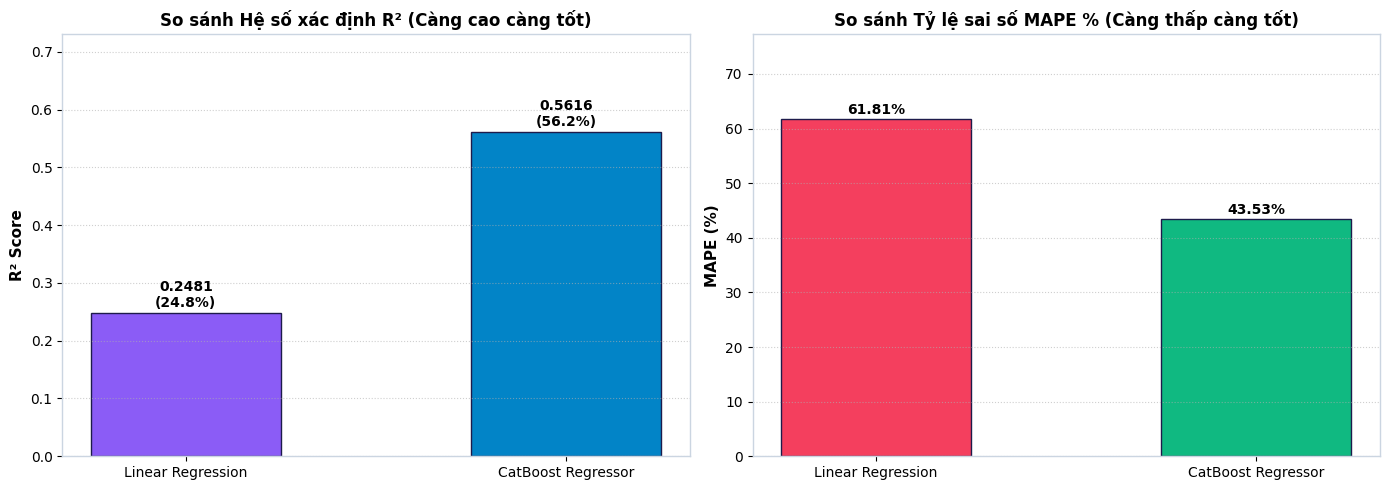

In [17]:
# ============================================================
# 15. BẢNG & BIỂU ĐỒ SO SÁNH ĐỐI ĐẦU: CATBOOST VS LINEAR REGRESSION
# ============================================================
# 1. Bảng so sánh chỉ số sạch, chuẩn duy nhất
comparison_metrics = pd.DataFrame({
    'Chỉ số đánh giá (Metric)': [
        'Hệ số xác định R² (Độ chính xác)',
        'MAE (Sai số tuyệt đối trung bình)',
        'RMSE (Sai số bình phương trung bình)',
        'MAPE (Tỷ lệ sai số phần trăm)'
    ],
    'CatBoost Regressor (Đề xuất)': [
        f"{R2:.4f} ({R2*100:.2f}%)",
        f"${MAE:,.2f}",
        f"${RMSE:,.2f}",
        f"{MAPE:.2f}%"
    ],
    'Linear Regression (Cơ sở)': [
        f"{R2_lr:.4f} ({R2_lr*100:.2f}%)",
        f"${MAE_lr:,.2f}",
        f"${RMSE_lr:,.2f}",
        f"{MAPE_lr:.2f}%"
    ],
    'Mức độ cải thiện của CatBoost': [
        f"+{(R2 - R2_lr)*100:.2f}% (Tốt hơn)",
        f"-${(MAE_lr - MAE):,.2f} (Giảm sai số)",
        f"-${(RMSE_lr - RMSE):,.2f} (Giảm sai số)",
        f"-{(MAPE_lr - MAPE):.2f}% (Chính xác hơn)"
    ]
})

print("="*85)
print("                 BẢNG SO SÁNH HIỆU NĂNG GIỮA 2 THUẬT TOÁN")
print("="*85)
display(comparison_metrics)

# 2. Biểu đồ cột so sánh trực quan R² Score và MAPE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ R2 Score
models = ['Linear Regression', 'CatBoost Regressor']
r2_values = [max(0, R2_lr), R2]
colors = ['#8b5cf6', '#0284c7']

axes[0].bar(models, r2_values, color=colors, width=0.5, edgecolor='#1e1b4b')
axes[0].set_title('So sánh Hệ số xác định R² (Càng cao càng tốt)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(R2, R2_lr) * 1.3)
for i, v in enumerate(r2_values):
    axes[0].text(i, v + 0.01, f"{v:.4f}\n({v*100:.1f}%)", ha='center', fontweight='bold', fontsize=10)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Biểu đồ MAPE (Sai số %)
mape_values = [MAPE_lr, MAPE]
axes[1].bar(models, mape_values, color=['#f43f5e', '#10b981'], width=0.5, edgecolor='#1e1b4b')
axes[1].set_title('So sánh Tỷ lệ sai số MAPE % (Càng thấp càng tốt)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAPE (%)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, max(mape_values) * 1.25)
for i, v in enumerate(mape_values):
    axes[1].text(i, v + 0.8, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=10)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
